<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2025/blob/main/DCGL_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="inicio"></a>
## **a.** [Abajo](#Tx)

## **1.** [Diseño en Cuadrado Greco Latino - DCGL](#T1)
## **2.** [Datos del Problema](#T2)
## **3.** [Tabla Anova](#T3)

[⬆️ Arriba](#inicio)

<a name="T1"></a>

## **1. Diseño en Cuadrado Greco Latino - DCGL**

# Diseño Experimental: Cuadrado Grecolatino para el Estudio de Formulaciones Propulsoras

Este experimento se diseñó para investigar el efecto de cinco **Formulaciones** diferentes (A, B, C, D, E) de carga propulsora sobre la rapidez de combustión en sistemas de expulsión de tripulación de aviones. El objetivo es aislar el efecto de cada formulación minimizando la influencia de factores perturbadores.

## Factores y Niveles

*   **Factor de Interés:** Formulaciones (A, B, C, D, E)
*   **Factores de Bloqueo (Factores Perturbadores):**
    *   Lotes de Materia Prima (1, 2, 3, 4, 5)
    *   Operadores (1, 2, 3, 4, 5)
    *   Montajes de Prueba (α, β, γ, δ, ε)

## Diseño Experimental: Cuadrado Grecolatino

Se empleó un diseño de Cuadrado Grecolatino para controlar simultáneamente la variabilidad debida a los lotes de materia prima, los operadores y los montajes de prueba. Este diseño asegura que cada formulación, cada lote, cada operador y cada montaje de prueba aparezcan exactamente una vez en cada fila (Operador) y cada columna (Lote).

La estructura del diseño se presenta en la siguiente tabla:

**Tabla 6. Diseño en cuadro grecolatino**

| (Operador\Lote) | 1     | 2     | 3     | 4     | 5     |
| :-------------- | :---- | :---- | :---- | :---- | :---- |
| **1**           | Aα=24 | Bγ=20 | Cε=19 | Dβ=24 | Eδ=24 |
| **2**           | Bβ=17 | Cδ=24 | Dα=30 | Eγ=27 | Aε=36 |
| **3**           | Cγ=18 | Dε=38 | Eβ=26 | Aδ=27 | Bα=21 |
| **4**           | Dδ=26 | Eα=31 | Aγ=26 | Bε=23 | Cβ=22 |
| **5**           | Eε=22 | Aβ=30 | Bδ=20 | Cα=29 | Dγ=31 |

**Interpretación de la Tabla:**

Cada celda de la tabla representa una combinación única de Operador, Lote, Formulación y Montaje de Prueba, junto con el resultado observado (rapidez de combustión). Por ejemplo, la celda en la fila 1 y columna 1 indica que el Operador 1 utilizó el Lote 1 con la Formulación A y el Montaje de Prueba α, obteniendo una rapidez de combustión de 24.

## Análisis

El diseño de Cuadrado Grecolatino permite realizar un análisis de varianza (ANOVA) para determinar si existen diferencias estadísticamente significativas en la rapidez de combustión entre las diferentes formulaciones, controlando al mismo tiempo el efecto de los lotes, operadores y montajes de prueba.

[⬆️ Arriba](#inicio)

<a name="T2"></a>

## **2. Datos del Problema**

In [1]:
# @title **Datos para el DCGL**
import pandas as pd

data = {
    'Operador': [1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5],
    'Lote': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'Formulacion': ['A', 'B', 'C', 'D', 'E', 'B', 'C', 'D', 'E', 'A', 'C', 'D', 'E', 'A', 'B', 'D', 'E', 'A', 'B', 'C', 'E', 'A', 'B', 'C', 'D'],
    'Montaje': ['α', 'γ', 'ε', 'β', 'δ', 'β', 'δ', 'α', 'γ', 'ε', 'γ', 'ε', 'β', 'δ', 'α', 'δ', 'α', 'γ', 'ε', 'β', 'ε', 'β', 'δ', 'α', 'γ'],
    'Rapidez_Combustion': [24, 20, 19, 24, 24, 17, 24, 30, 27, 36, 18, 38, 26, 27, 21, 26, 31, 26, 23, 22, 22, 30, 20, 29, 31]
}

df = pd.DataFrame(data)
display(df)

,Operador,Lote,Formulacion,Montaje,Rapidez_Combustion
0,1,1,A,α,24
1,1,2,B,γ,20
2,1,3,C,ε,19
3,1,4,D,β,24
4,1,5,E,δ,24
5,2,1,B,β,17
6,2,2,C,δ,24
7,2,3,D,α,30
8,2,4,E,γ,27
9,2,5,A,ε,36


In [14]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [15]:
%%R
# Cargar el archivo CSV en un DataFrame de R
df_r <- read.csv('rapidez_combustion_data.csv')

# Mostrar las primeras filas del DataFrame de R
print(head(df_r))

  Operador Lote Formulacion Montaje Rapidez_Combustion
1        1    1           A       α                 24
2        1    2           B       γ                 20
3        1    3           C       ε                 19
4        1    4           D       β                 24
5        1    5           E       δ                 24
6        2    1           B       β                 17


In [17]:
%%R
# Realizar el análisis de varianza (ANOVA) en R
# Asegúrate de que las columnas de factores se traten como factores
df_r$Operador <- as.factor(df_r$Operador)
df_r$Lote <- as.factor(df_r$Lote)
df_r$Formulacion <- as.factor(df_r$Formulacion)
df_r$Montaje <- as.factor(df_r$Montaje)

# Ajustar el modelo ANOVA
# La fórmula incluye los factores principales
modelo_r <- aov(Rapidez_Combustion ~ Formulacion + Operador + Lote + Montaje, data = df_r)

# Mostrar el resumen del ANOVA
print(summary(modelo_r))

            Df Sum Sq Mean Sq F value  Pr(>F)   
Formulacion  4    330   82.50  10.000 0.00334 **
Operador     4     68   17.00   2.061 0.17831   
Lote         4    150   37.50   4.545 0.03293 * 
Montaje      4     62   15.50   1.879 0.20764   
Residuals    8     66    8.25                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [19]:
%%R
# Realizar la prueba HSD de Tukey
# El argumento "Formulacion" especifica el factor para el cual queremos las comparaciones por pares
tukey_result_r <- TukeyHSD(modelo_r, "Formulacion")

# Mostrar los resultados de la prueba HSD
print(tukey_result_r)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Rapidez_Combustion ~ Formulacion + Operador + Lote + Montaje, data = df_r)

$Formulacion
    diff        lwr         upr     p adj
B-A -8.4 -14.675865 -2.12413503 0.0107829
C-A -6.2 -12.475865  0.07586497 0.0529245
D-A  1.2  -5.075865  7.47586497 0.9596565
E-A -2.6  -8.875865  3.67586497 0.6270350
C-B  2.2  -4.075865  8.47586497 0.7462701
D-B  9.6   3.324135 15.87586497 0.0048412
E-B  5.8  -0.475865 12.07586497 0.0714956
D-C  7.4   1.124135 13.67586497 0.0218416
E-C  3.6  -2.675865  9.87586497 0.3525524
E-D -3.8 -10.075865  2.47586497 0.3087315



In [20]:
%%R
# Realizar la prueba HSD de Tukey
# El argumento "Formulacion" especifica el factor para el cual queremos las comparaciones por pares
tukey_result_r <- TukeyHSD(modelo_r, "Lote")

# Mostrar los resultados de la prueba HSD
print(tukey_result_r)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Rapidez_Combustion ~ Formulacion + Operador + Lote + Montaje, data = df_r)

$Lote
    diff        lwr       upr     p adj
2-1  7.2   0.924135 13.475865 0.0252496
3-1  2.8  -3.475865  9.075865 0.5669444
4-1  4.6  -1.675865 10.875865 0.1753581
5-1  5.4  -0.875865 11.675865 0.0966410
3-2 -4.4 -10.675865  1.875865 0.2028079
4-2 -2.6  -8.875865  3.675865 0.6270350
5-2 -1.8  -8.075865  4.475865 0.8524755
4-3  1.8  -4.475865  8.075865 0.8524755
5-3  2.6  -3.675865  8.875865 0.6270350
5-4  0.8  -5.475865  7.075865 0.9906712



In [11]:
# Guardar el DataFrame a un archivo CSV
df.to_csv('rapidez_combustion_data.csv', index=False)

print("DataFrame guardado como 'rapidez_combustion_data.csv'")

DataFrame guardado como 'rapidez_combustion_data.csv'


[⬆️ Arriba](#inicio)

<a name="T3"></a>
##**Tabla Anova**

In [3]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Convertir las columnas de factores a tipo 'category' para el ANOVA
df['Operador'] = df['Operador'].astype('category')
df['Lote'] = df['Lote'].astype('category')
df['Formulacion'] = df['Formulacion'].astype('category')
df['Montaje'] = df['Montaje'].astype('category')

# Ajustar el modelo ANOVA
# La fórmula incluye los factores principales (Formulacion, Operador, Lote, Montaje)
modelo = ols('Rapidez_Combustion ~ C(Formulacion) + C(Operador) + C(Lote) + C(Montaje)', data=df).fit()

# Realizar el análisis de varianza
anova_table = sm.stats.anova_lm(modelo, typ=1)

# Mostrar la tabla ANOVA
display(anova_table)

,df,sum_sq,mean_sq,F,PR(>F)
C(Formulacion),4.0,330.0,82.50,10.000000,0.003344
C(Operador),4.0,68.0,17.00,2.060606,0.178311
C(Lote),4.0,150.0,37.50,4.545455,0.032930
C(Montaje),4.0,62.0,15.50,1.878788,0.207641
Residual,8.0,66.0,8.25,NaN,NaN


## **Interpretación del Anova**

+ C(Formulacion): El p-valor es 0.003344. Al ser menor que 0.05, concluimos que las diferentes Formulaciones tienen un efecto significativo en la rapidez de combustión.
+ C(Operador): El p-valor es 0.178311. Al ser mayor que 0.05, no hay evidencia de que los Operadores tengan un efecto significativo.
+ C(Lote): El p-valor es 0.032930. Al ser menor que 0.05, los diferentes Lotes de Materia Prima tienen un efecto significativo en la rapidez de combustión.
+ C(Montaje): El p-valor es 0.207641. Al ser mayor que 0.05, no hay evidencia de que los Montajes de Prueba tengan un efecto significativo.
+ En resumen, las Formulaciones y los Lotes son los únicos factores que impactan significativamente la rapidez de combustión según este análisis.


[⬆️ Arriba](#inicio)

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Realizar la prueba HSD de Tukey para Formulacion
# 'endog' es la variable dependiente (Rapidez_Combustion)
# 'groups' es la variable categórica (Formulacion)
# 'alpha' es el nivel de significancia (0.05 por defecto)
tukey_result = pairwise_tukeyhsd(endog=df['Rapidez_Combustion'], groups=df['Formulacion'], alpha=0.05)

# Mostrar los resultados
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B     -8.4 0.0329 -16.2717 -0.5283   True
     A      C     -6.2 0.1685 -14.0717  1.6717  False
     A      D      1.2 0.9904  -6.6717  9.0717  False
     A      E     -2.6 0.8574 -10.4717  5.2717  False
     B      C      2.2 0.9161  -5.6717 10.0717  False
     B      D      9.6 0.0123   1.7283 17.4717   True
     B      E      5.8 0.2182  -2.0717 13.6717  False
     C      D      7.4 0.0717  -0.4717 15.2717  False
     C      E      3.6 0.6536  -4.2717 11.4717  False
     D      E     -3.8 0.6077 -11.6717  4.0717  False
-----------------------------------------------------


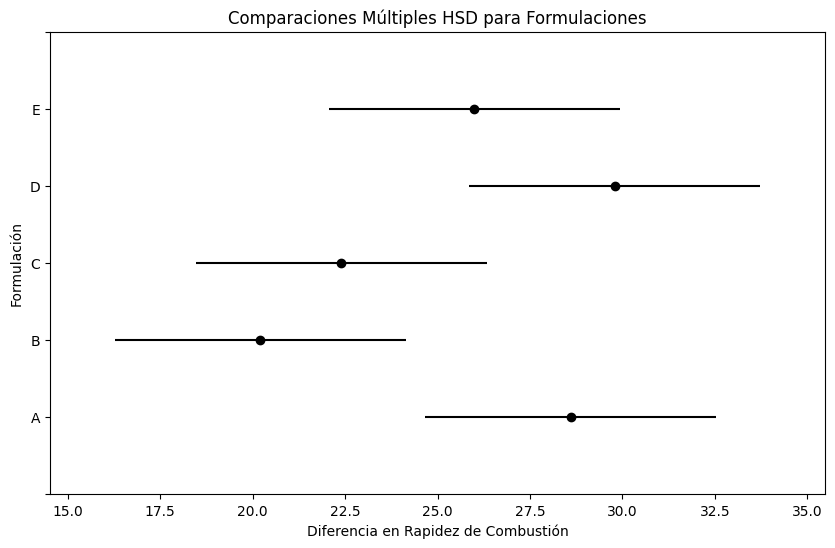

In [9]:
import matplotlib.pyplot as plt

# Crear el gráfico de comparaciones múltiples HSD
tukey_result.plot_simultaneous()

# Personalizar el gráfico
plt.title('Comparaciones Múltiples HSD para Formulaciones')
plt.xlabel('Diferencia en Rapidez de Combustión')
plt.ylabel('Formulación')

# Mostrar el gráfico
plt.show()

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2      7.2 0.2129  -2.5056 16.9056  False
     1      3      2.8 0.9069  -6.9056 12.5056  False
     1      4      4.6 0.6236  -5.1056 14.3056  False
     1      5      5.4 0.4762  -4.3056 15.1056  False
     2      3     -4.4 0.6607 -14.1056  5.3056  False
     2      4     -2.6 0.9271 -12.3056  7.1056  False
     2      5     -1.8   0.98 -11.5056  7.9056  False
     3      4      1.8   0.98  -7.9056 11.5056  False
     3      5      2.6 0.9271  -7.1056 12.3056  False
     4      5      0.8 0.9991  -8.9056 10.5056  False
-----------------------------------------------------


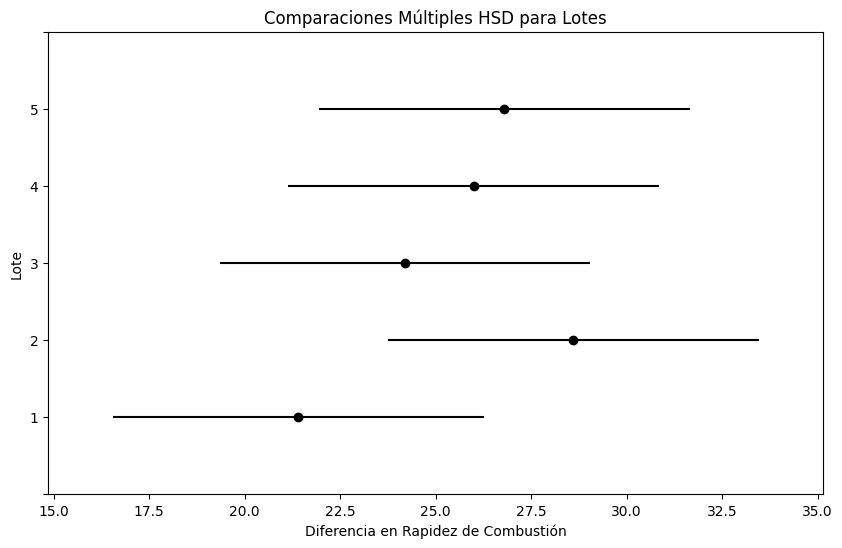

In [10]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Realizar la prueba HSD de Tukey para Lote
# 'endog' es la variable dependiente (Rapidez_Combustion)
# 'groups' es la variable categórica (Lote)
# 'alpha' es el nivel de significancia (0.05 por defecto)
tukey_lote_result = pairwise_tukeyhsd(endog=df['Rapidez_Combustion'], groups=df['Lote'], alpha=0.05)

# Mostrar los resultados de la prueba HSD para Lote
print(tukey_lote_result)

# Crear el gráfico de comparaciones múltiples HSD para Lote
tukey_lote_result.plot_simultaneous()

# Personalizar el gráfico
plt.title('Comparaciones Múltiples HSD para Lotes')
plt.xlabel('Diferencia en Rapidez de Combustión')
plt.ylabel('Lote')

# Mostrar el gráfico
plt.show()

[⬆️ Arriba](#inicio)

[⬆️ Arriba](#inicio)

<a name="Tx"></a>



##**Abajo**

<a name="T2"></a>

## **2. Datos del Problema**